## PARTE 1: NUMPY

## Ejercicio 1
¿Cuál es el tamaño en bytes de un array de 1000 elementos de tipo booleano?

In [1]:
import numpy as np

arr = np.ones(1000, dtype=bool)
print(arr.nbytes)

1000


## Ejercicio 2
Cree un array cuyos elementos sean los enteros pares en [1,100] en orden decreciente. Muestre los 10 últimos.

In [3]:
arr = np.arange(2, 101, 2)[::-1]
print(arr[-10:])

[20 18 16 14 12 10  8  6  4  2]


## Ejercicio 3
Seleccionar subarrays específicos.

In [4]:
arr = np.array([
    [2,4,5,6],
    [0,3,7,4],
    [8,8,5,2],
    [1,5,6,1]
])

sub1 = arr[1]
print(sub1)

sub2 = arr[[0,2]][:, [0,2]]
print(sub2)

[0 3 7 4]
[[2 5]
 [8 5]]


## Ejercicio 4
Media aritmética de (a - b).

In [5]:
a = np.array([1,4,2,7])
b = np.array([1,3,2,9])

print(np.mean(a - b))

-0.25


## Ejercicio 5
Agregar coordenadas y mostrar dimensiones.

In [6]:
coords = np.array([
    [1.33, 4.5],
    [30.0, 10.7],
    [70.2, 0.5]
])

nuevo = np.vstack([coords, [37.1, -3.6]])
print(nuevo.shape)

(4, 2)


## Ejercicio 6
Transponer y agregar nuevas coordenadas.

In [7]:
transpuesta = nuevo.T

final = np.vstack([transpuesta.T, [10.8, 3.0], [35.8, 12.0]])
print(final)

[[ 1.33  4.5 ]
 [30.   10.7 ]
 [70.2   0.5 ]
 [37.1  -3.6 ]
 [10.8   3.  ]
 [35.8  12.  ]]


## PARTE 2: PANDAS Y MATPLOTLIB

## Cargar dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NucleosPoblacion.csv")
df.head()

,FID,OBJECTID,Texto,Poblacion,CodMun,Municipio,CodProvin,Provincia,X,Y
0,0,1,Agüimes,29431.0,35002,Agüimes,35,Las Palmas,-15.446012,27.900542
1,1,2,Antigua,10458.0,35003,Antigua,35,Las Palmas,-14.013301,28.418966
2,2,3,Arrecife,58156.0,35004,Arrecife,35,Las Palmas,-13.551451,28.960649
3,3,4,Arucas,36745.0,35006,Arucas,35,Las Palmas,-15.521512,28.117496
4,4,5,Gáldar,24473.0,35009,Gáldar,35,Las Palmas,-15.654111,28.143873


## Ejercicio 1
Municipios con más de 100000 habitantes.

In [10]:
print((df["Poblacion"] > 100000).sum())

62


## Ejercicio 2
Gráfica de población y ranking de ciudades.

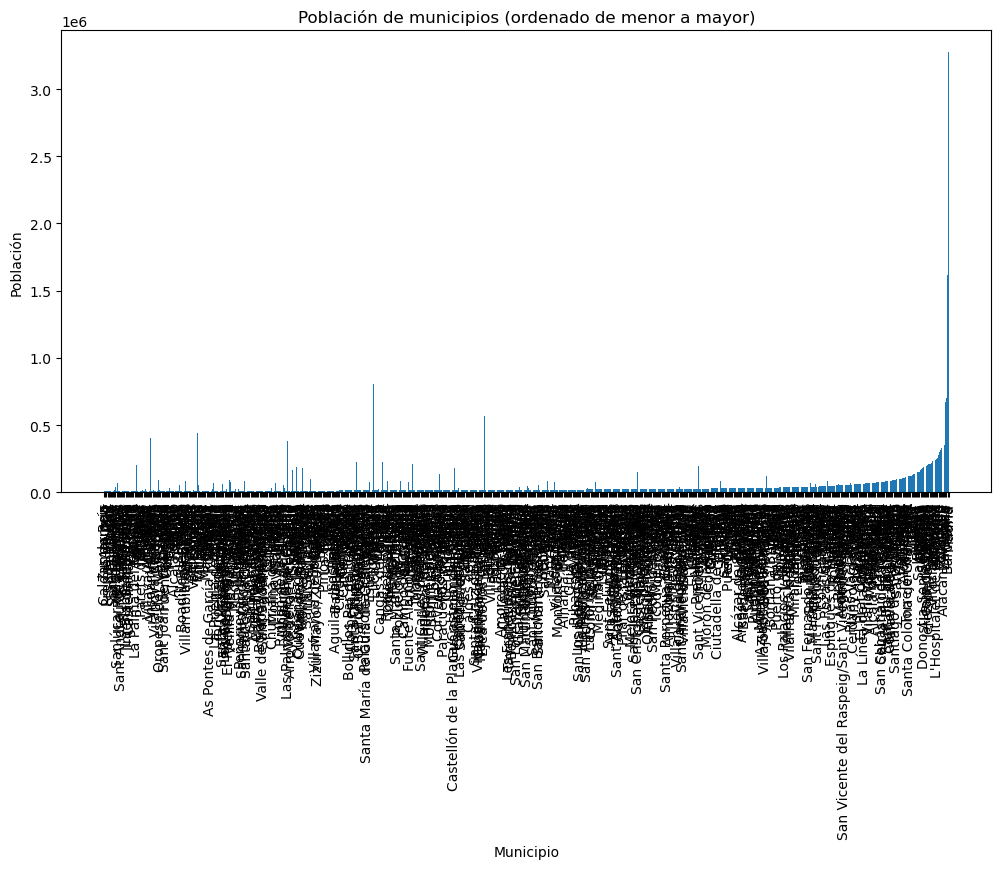

In [13]:
df_sorted = df.sort_values("Poblacion")

plt.figure(figsize=(12,6))
plt.bar(df_sorted["Municipio"], df_sorted["Poblacion"])
plt.xticks(rotation=90)
plt.xlabel("Municipio")
plt.ylabel("Población")
plt.title("Población de municipios (ordenado de menor a mayor)")
plt.show()

### a) Segunda ciudad más poblada

In [14]:
segunda = df.sort_values("Poblacion", ascending=False).iloc[1]["Municipio"]
print(segunda)

Barcelona


### b) Posición de Granada en el ranking

In [15]:
ranking = df.sort_values("Poblacion", ascending=False).reset_index(drop=True)
posicion = ranking[ranking["Municipio"] == "Granada"].index[0] + 1
print(posicion)

18


## Ejercicio 3
¿Cuántos municipios de Extremadura tienen más de 5000 habitantes?

In [17]:
extremadura = df[
    (df["Provincia"].isin(["Badajoz", "Cáceres"])) &
    (df["Poblacion"] > 5000)
]

print(extremadura.shape[0])

14


## Ejercicio 4
Municipio situado más al Norte.

In [18]:
norte = df.loc[df["Y"].idxmax()]

print("Municipio:", norte["Municipio"])
print("Provincia:", norte["Provincia"])
print("Población:", norte["Poblacion"])

Municipio: Viveiro
Provincia: Lugo
Población: 16211.0


## Ejercicio 5
Estadísticas de la población en Granada.

In [19]:
granada = df[df["Provincia"] == "Granada"]["Poblacion"]

print("Media:", granada.mean())
print("Mediana:", granada.median())
print("Desviación estándar:", granada.std())
print("Máximo:", granada.max())
print("Mínimo:", granada.min())

Media: 30217.85
Mediana: 17526.0
Desviación estándar: 50355.49171459277
Máximo: 239154.0
Mínimo: 10386.0


## Ejercicio 6
Histograma de población por provincia.

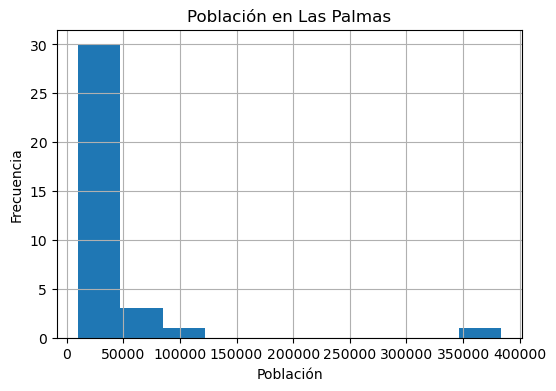

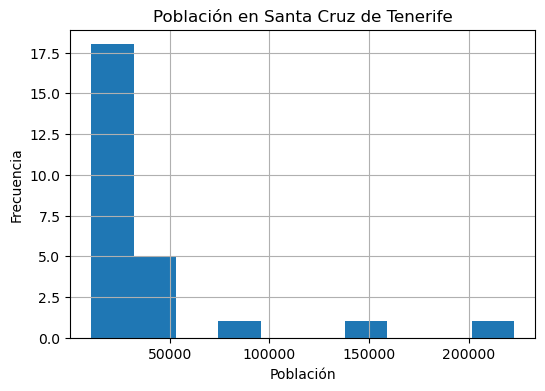

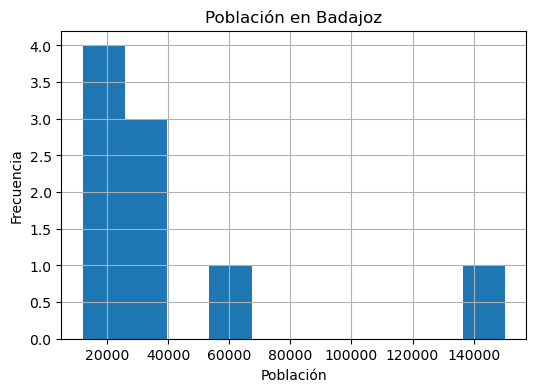

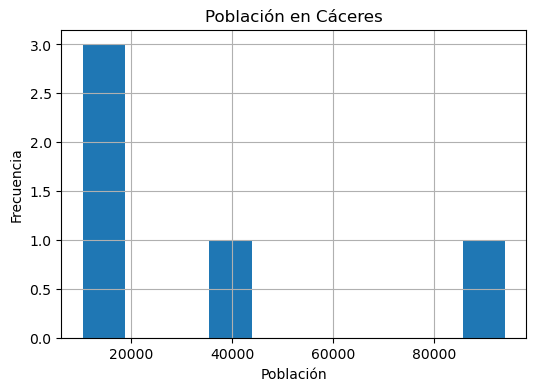

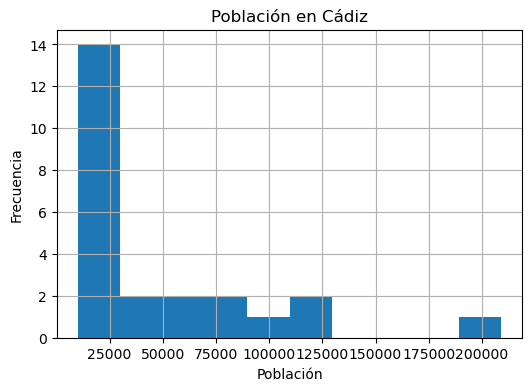

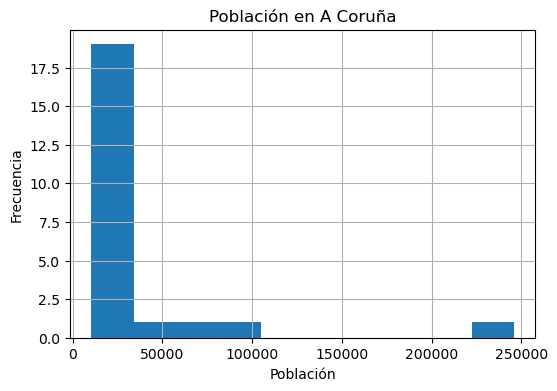

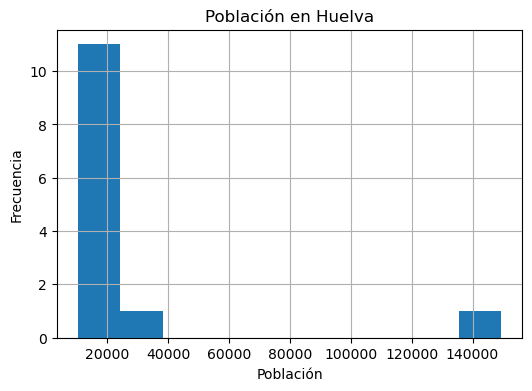

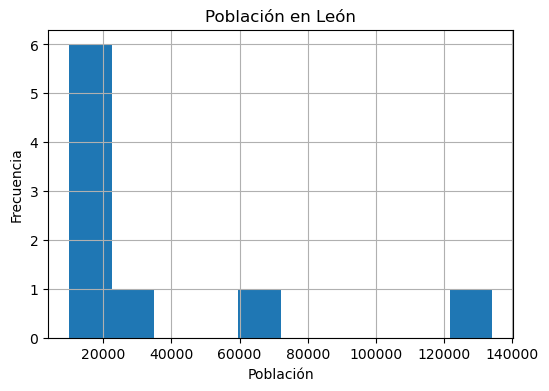

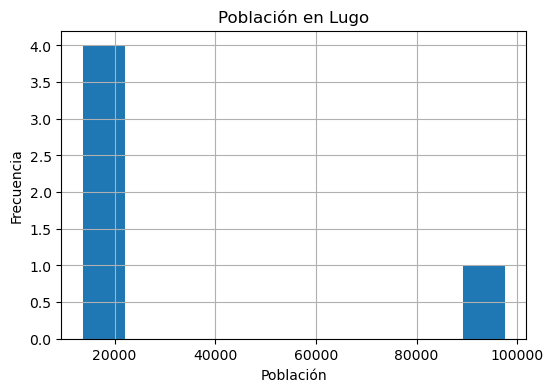

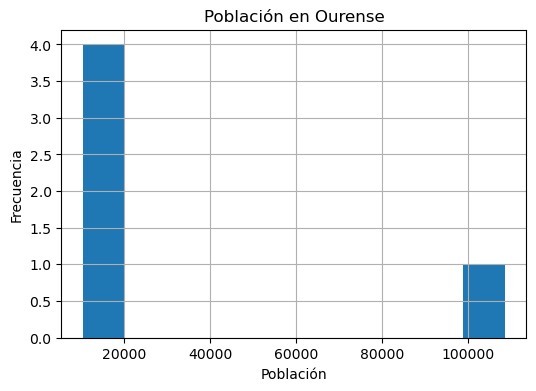

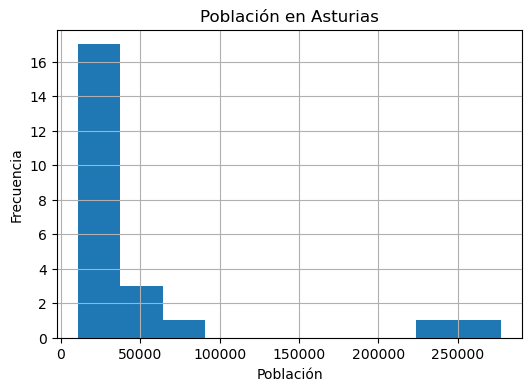

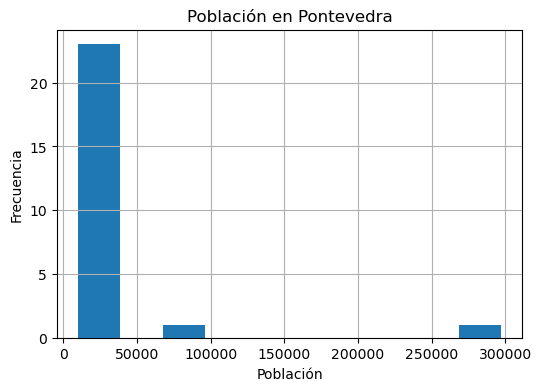

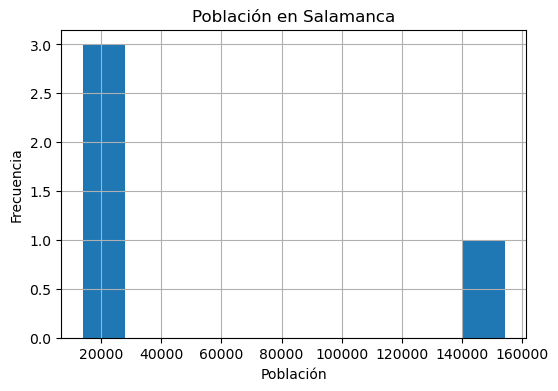

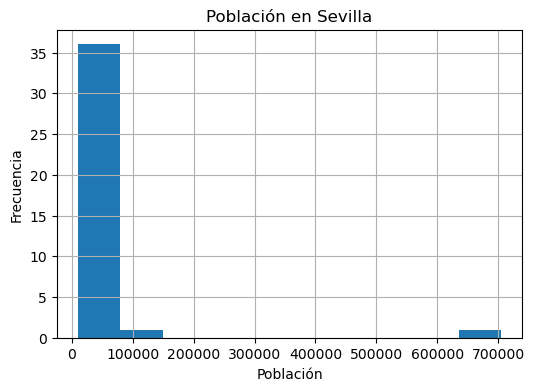

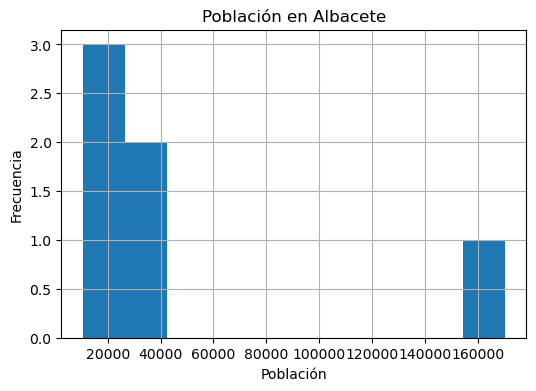

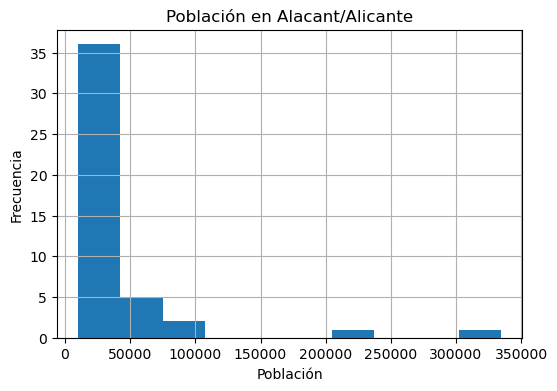

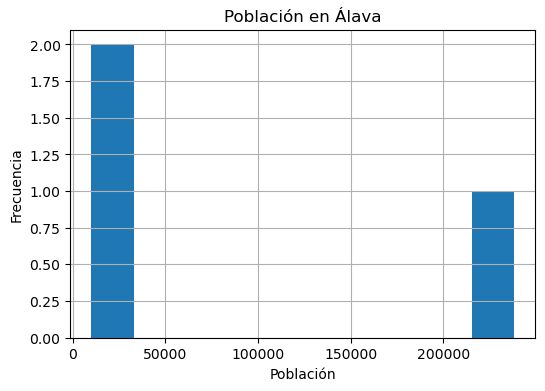

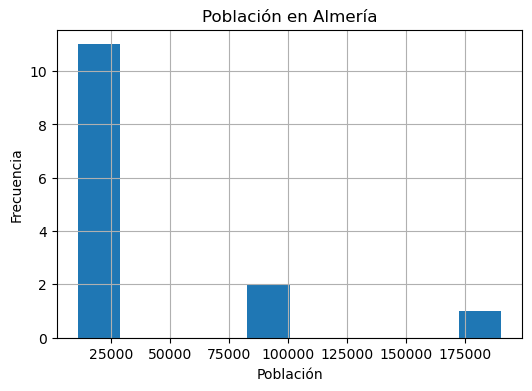

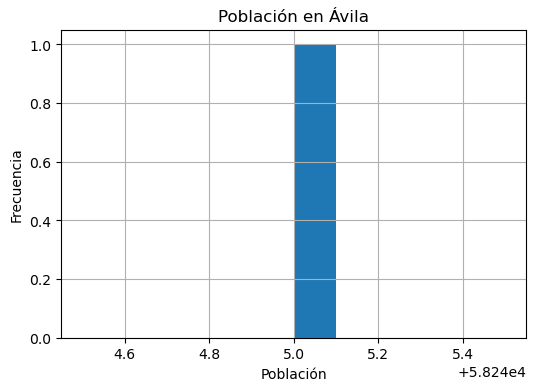

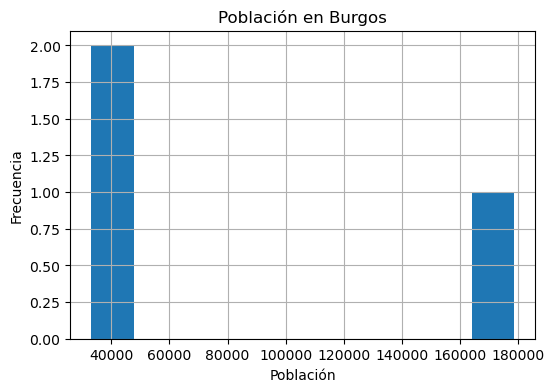

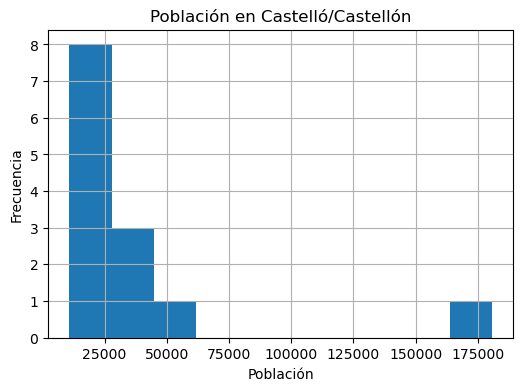

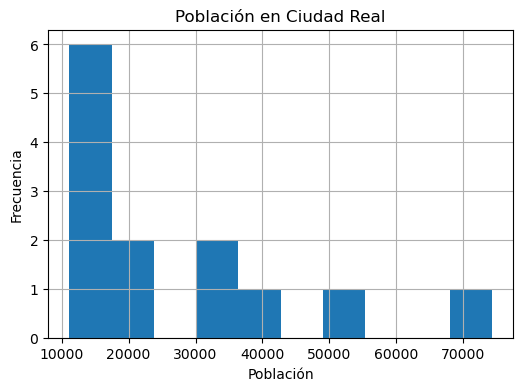

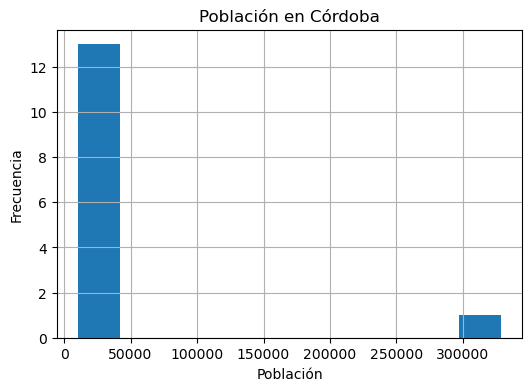

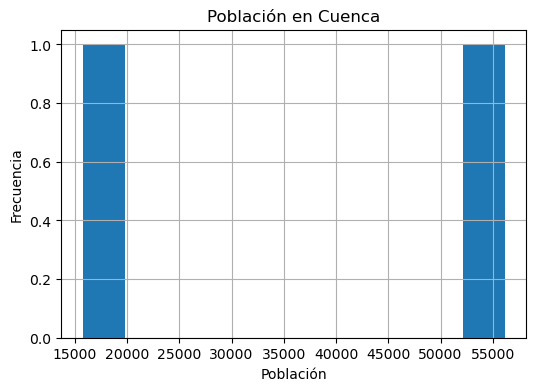

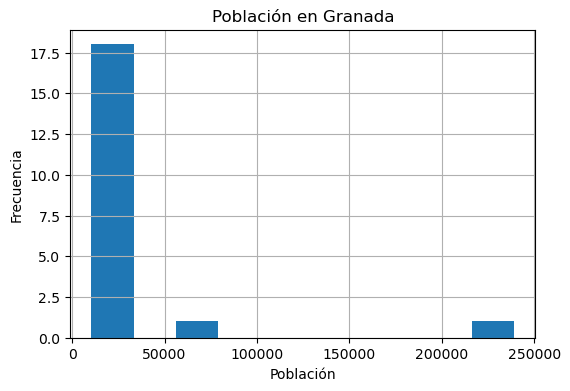

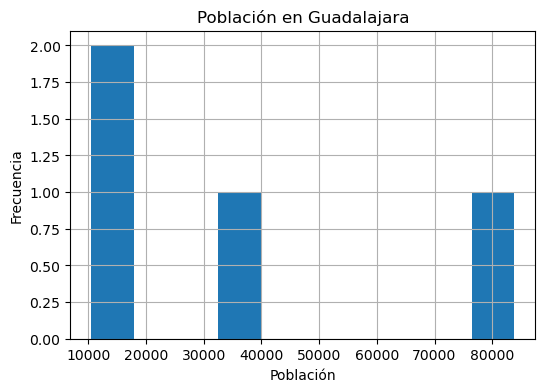

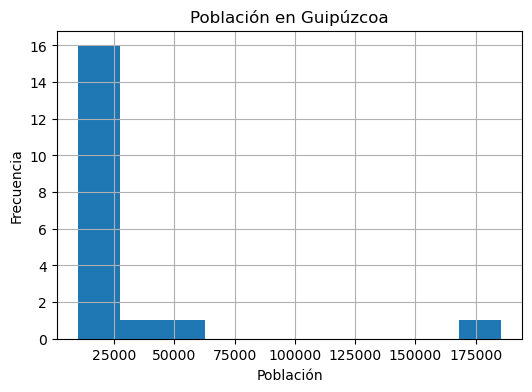

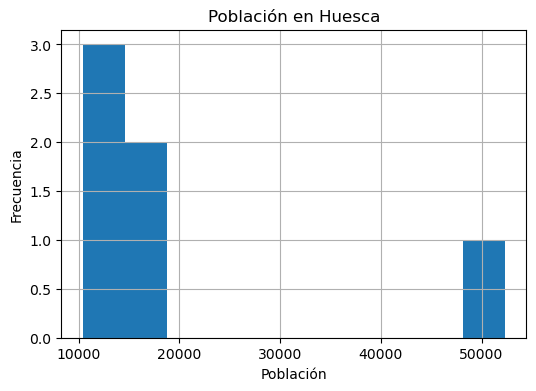

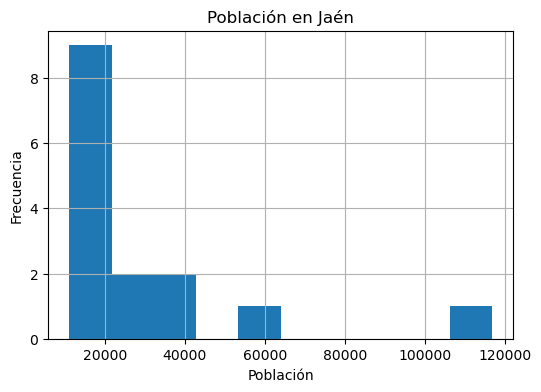

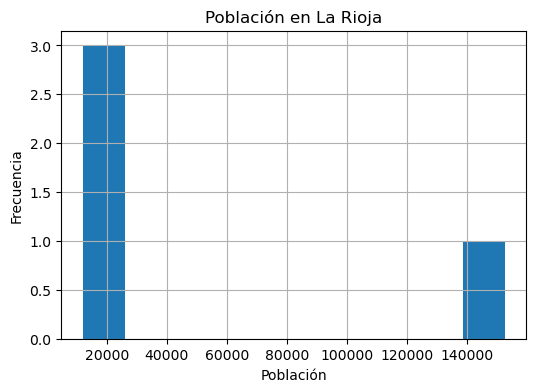

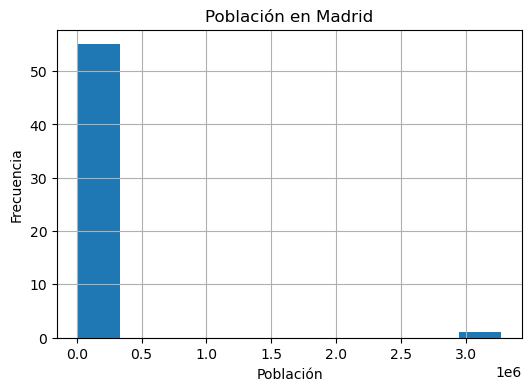

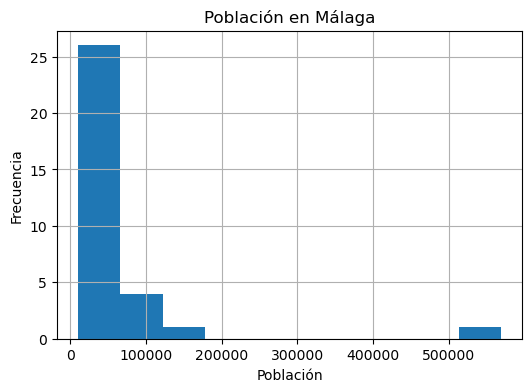

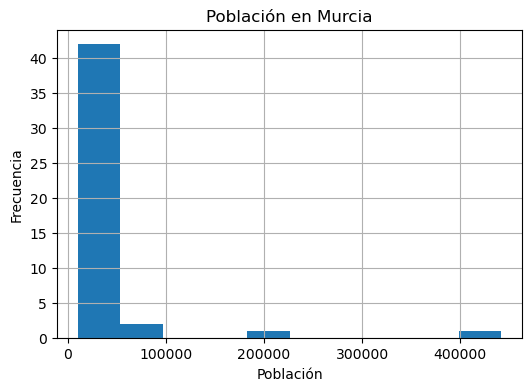

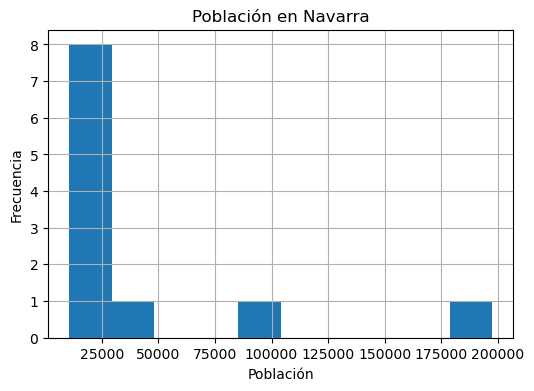

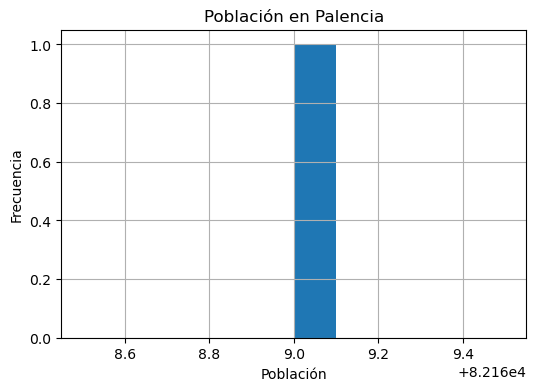

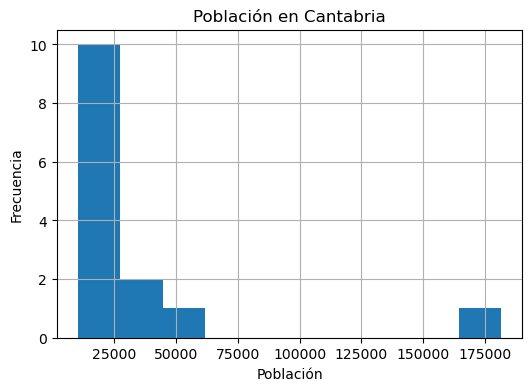

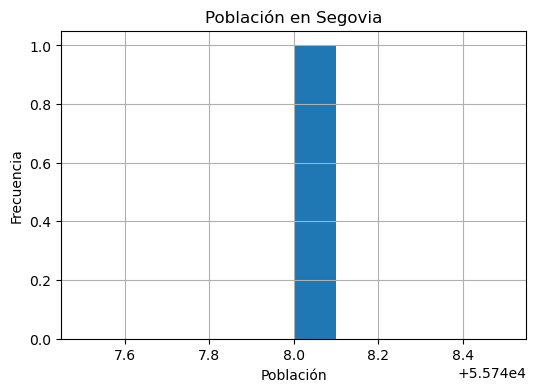

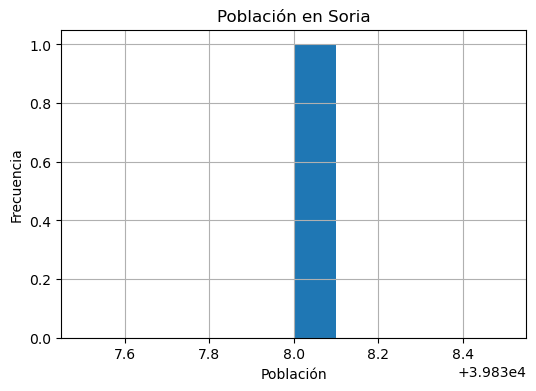

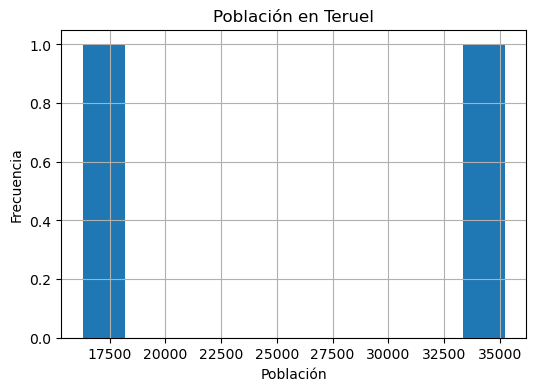

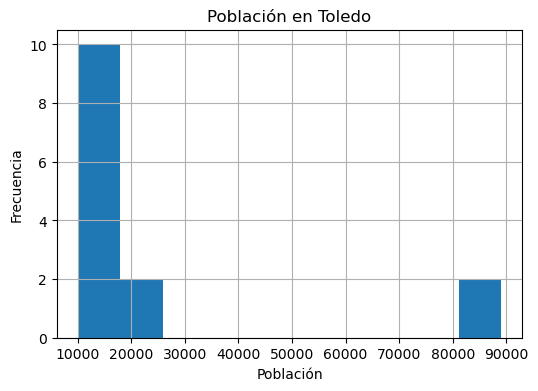

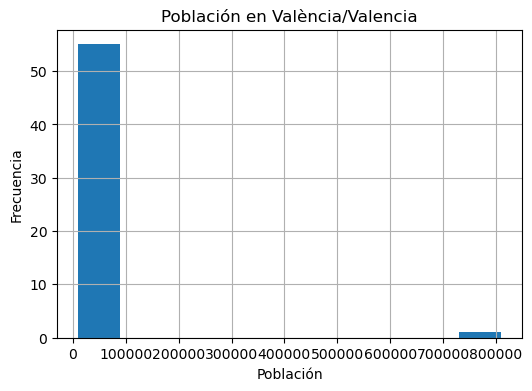

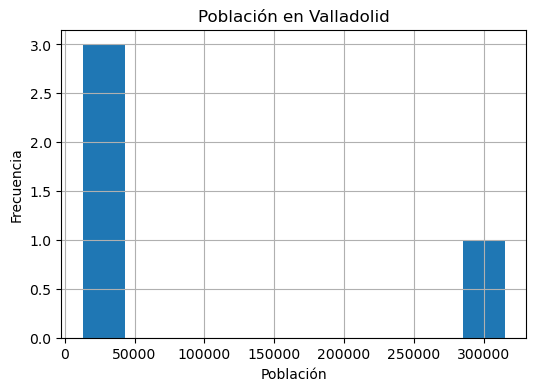

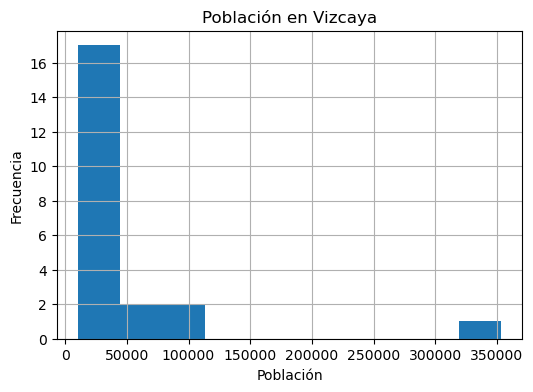

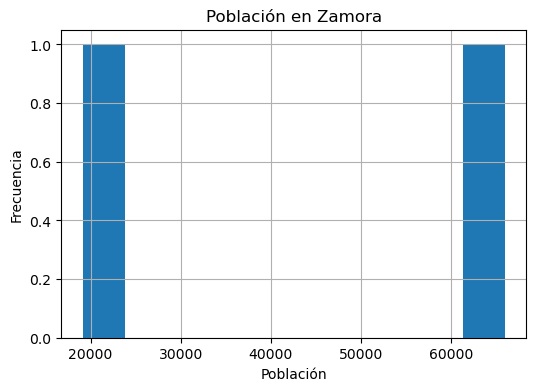

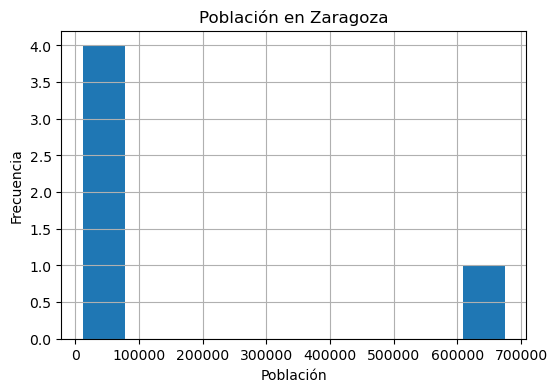

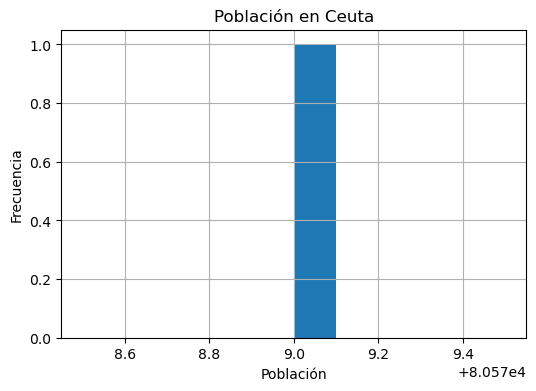

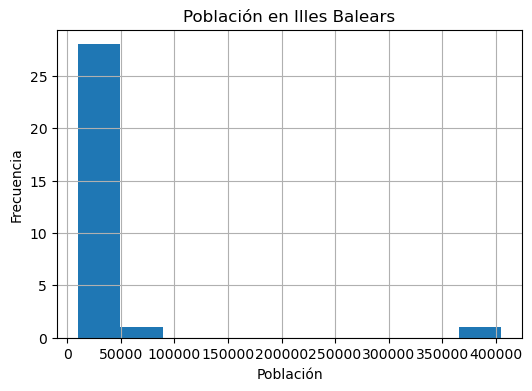

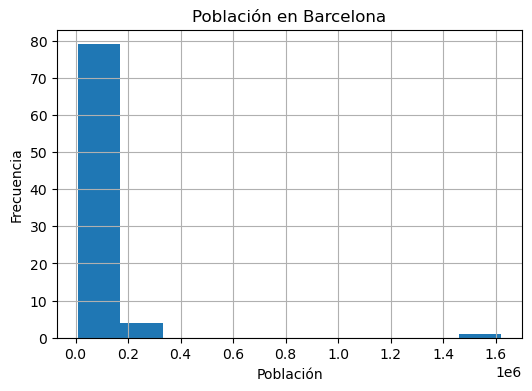

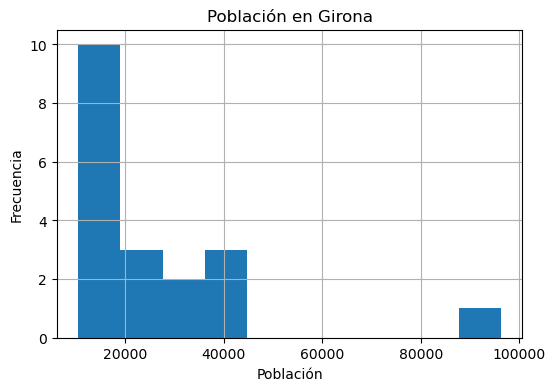

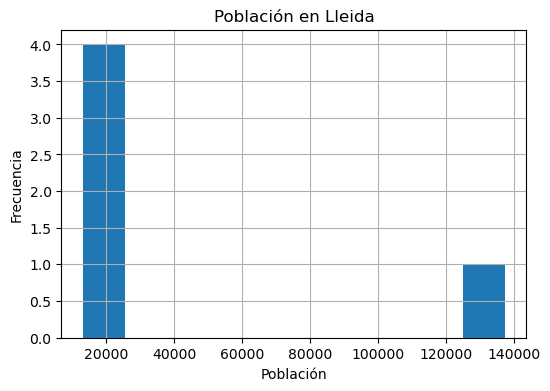

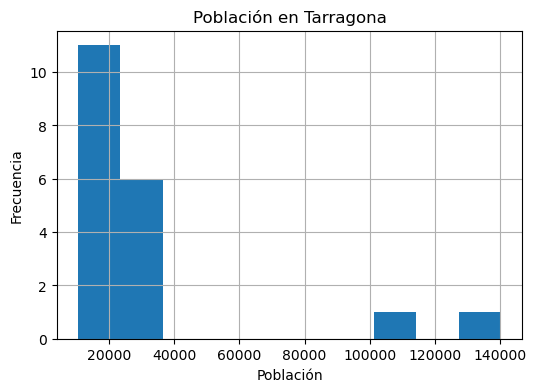

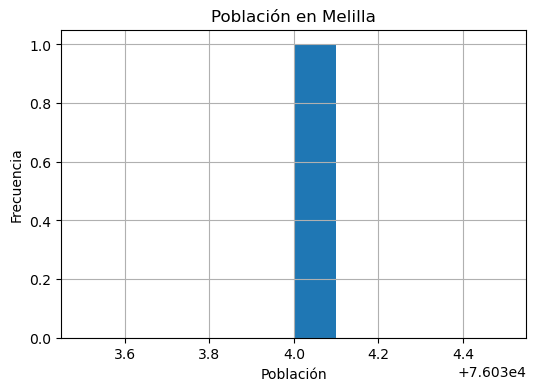

In [21]:
provincias = df["Provincia"].unique()

for p in provincias:
    plt.figure(figsize=(6,4))
    df[df["Provincia"] == p]["Poblacion"].hist()
    plt.title(f"Población en {p}")
    plt.xlabel("Población")
    plt.ylabel("Frecuencia")
    plt.show()

## Ejercicio 7
Promedio y desviación estándar de 50 municipios aleatorios.

In [22]:
sample = df.sample(50, replace=False)

print("Media:", sample["Poblacion"].mean())
print("Desviación estándar:", sample["Poblacion"].std())

Media: 45362.3
Desviación estándar: 72504.40029778067


## Ejercicio 8
Municipios más cercano y más lejano a Madrid.

In [25]:
import numpy as np

# Encontrar índice de Madrid (sin usar ==)
idx_madrid = df.index[df["Municipio"].str.contains("Madrid")][0]

# Obtener fila de Madrid
madrid = df.loc[idx_madrid]

# Calcular distancia SIN usar **
dx = df["X"] - madrid["X"]
dy = df["Y"] - madrid["Y"]

df["distancia"] = np.sqrt(dx*dx + dy*dy)

# Eliminar Madrid
df_no_madrid = df.drop(idx_madrid)

# Resultados
cercano = df_no_madrid.loc[df_no_madrid["distancia"].idxmin()]
lejano = df_no_madrid.loc[df_no_madrid["distancia"].idxmax()]

print("Más cercano:", cercano["Municipio"])
print("Más lejano:", lejano["Municipio"])

Más cercano: Fuenlabrada
Más lejano: Los Llanos de Aridane
